# COVID-19 Mexico — Data Visualization
**Internship:** CodeAlpha | **Task:** Task 3  
**Author:** Nouman Ali Arain | SBBU Nawabshah

In [3]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries imported!')

Libraries imported!


In [4]:
# 2. Load & Prepare Dataset
df = pd.read_csv("E:\Ineternship\Task 2\Covid Data.csv", low_memory=False)

df['DATE_DIED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce')
df['DIED']      = df['DATE_DIED'].notna().astype(int)
df['GENDER']    = df['SEX'].map({1: 'Female', 2: 'Male'})
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[0,18,30,45,60,75,120],
                         labels=['0-18','19-30','31-45','46-60','61-75','75+'],
                         right=False)

print('Dataset ready | Shape:', df.shape)

Dataset ready | Shape: (1048575, 24)


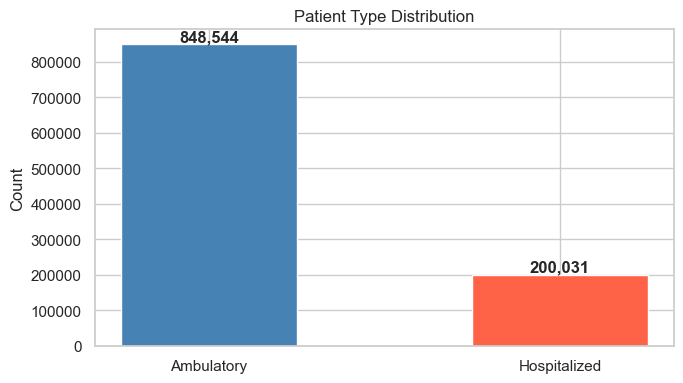

Insight: Majority of patients were ambulatory (mild cases).


In [5]:
# 3. Bar Chart — Patient Type Distribution
pt = df['PATIENT_TYPE'].map({1: 'Ambulatory', 2: 'Hospitalized'}).value_counts()

plt.figure(figsize=(7, 4))
plt.bar(pt.index, pt.values, color=['steelblue','tomato'], edgecolor='white', width=0.5)
for i, v in enumerate(pt.values):
    plt.text(i, v + max(pt)*0.01, f'{v:,}', ha='center', fontweight='bold')
plt.title('Patient Type Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Insight: Majority of patients were ambulatory (mild cases).')

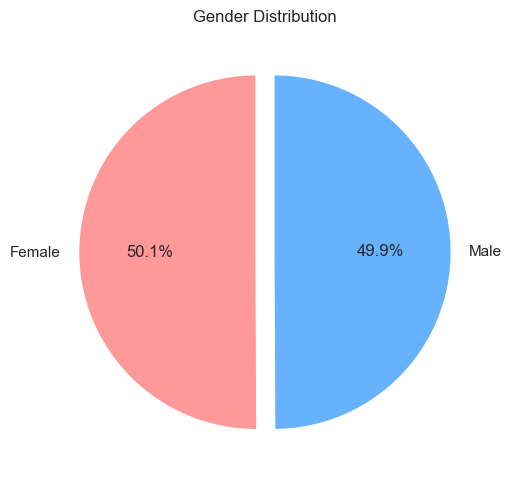

In [6]:
# 4. Pie Chart — Gender Distribution
gc = df['GENDER'].value_counts().dropna()

plt.figure(figsize=(6, 5))
plt.pie(gc.values, labels=gc.index, autopct='%1.1f%%',
        colors=['#FF9999','#66B2FF'], startangle=90, explode=[0.05]*len(gc))
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

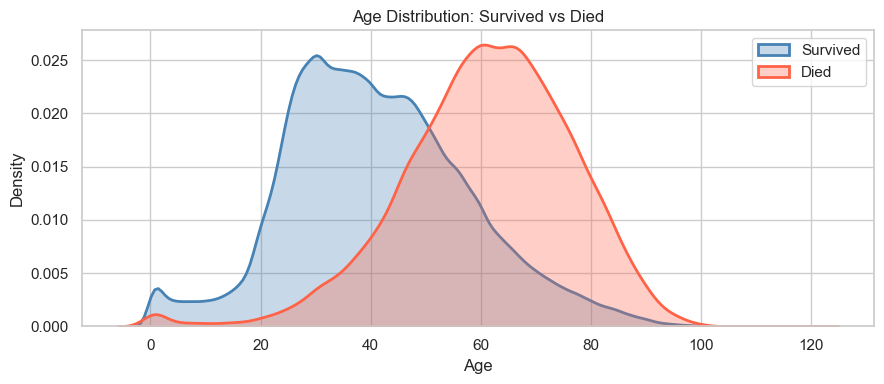

Insight: Deaths are concentrated in higher age groups (60+).


In [7]:
# 5. KDE Plot — Age Distribution by Outcome
plt.figure(figsize=(9, 4))
for outcome, color, label in [(0,'steelblue','Survived'), (1,'tomato','Died')]:
    subset = df[df['DIED']==outcome]['AGE'].dropna()
    sns.kdeplot(subset, color=color, fill=True, alpha=0.3, label=label, linewidth=2)
plt.title('Age Distribution: Survived vs Died')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()
print('Insight: Deaths are concentrated in higher age groups (60+).')

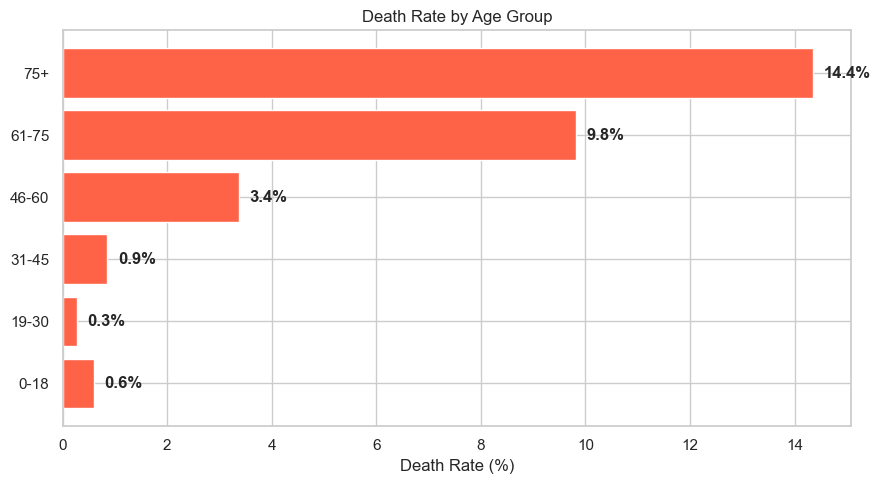

Insight: 75+ age group shows highest mortality rate.


In [8]:
# 6. Horizontal Bar — Death Rate by Age Group
death_rate = df.groupby('AGE_GROUP', observed=True)['DIED'].mean() * 100

plt.figure(figsize=(9, 5))
plt.barh(death_rate.index.astype(str), death_rate.values, color='tomato', edgecolor='white')
for i, v in enumerate(death_rate.values):
    plt.text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.title('Death Rate by Age Group')
plt.xlabel('Death Rate (%)')
plt.tight_layout()
plt.show()
print('Insight: 75+ age group shows highest mortality rate.')

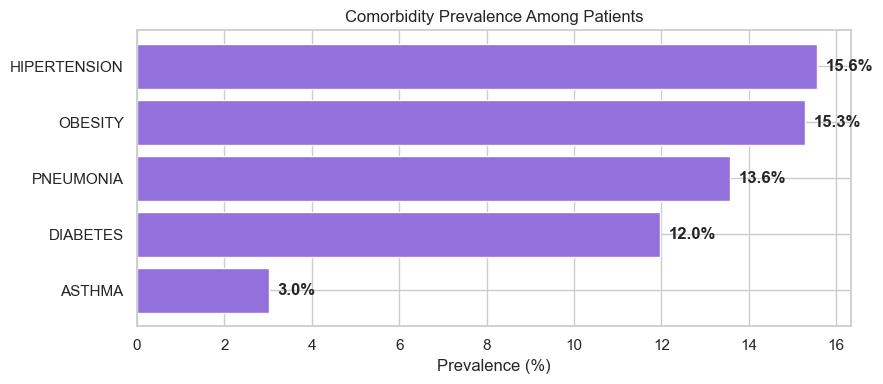

Insight: Hypertension and Diabetes are the most common comorbidities.


In [9]:
# 7. Horizontal Bar — Comorbidity Prevalence
comorbidities = ['DIABETES','HIPERTENSION','OBESITY','PNEUMONIA','ASTHMA']
available = [c for c in comorbidities if c in df.columns]

prev = {c: (df[c]==1).sum() / len(df[df[c].isin([1,2])]) * 100 for c in available}
ps   = pd.Series(prev).sort_values()

plt.figure(figsize=(9, 4))
plt.barh(ps.index, ps.values, color='mediumpurple', edgecolor='white')
for i, v in enumerate(ps.values):
    plt.text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.title('Comorbidity Prevalence Among Patients')
plt.xlabel('Prevalence (%)')
plt.tight_layout()
plt.show()
print('Insight: Hypertension and Diabetes are the most common comorbidities.')

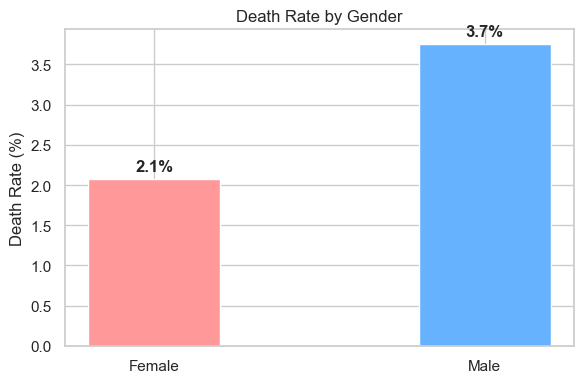

Insight: Males show slightly higher death rate than females.


In [10]:
# 8. Bar Chart — Death Rate by Gender
death_gender = df.groupby('GENDER', observed=True)['DIED'].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(death_gender.index, death_gender.values,
        color=['#FF9999','#66B2FF'], edgecolor='white', width=0.4)
for i, v in enumerate(death_gender.values):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Death Rate by Gender')
plt.ylabel('Death Rate (%)')
plt.tight_layout()
plt.show()
print('Insight: Males show slightly higher death rate than females.')

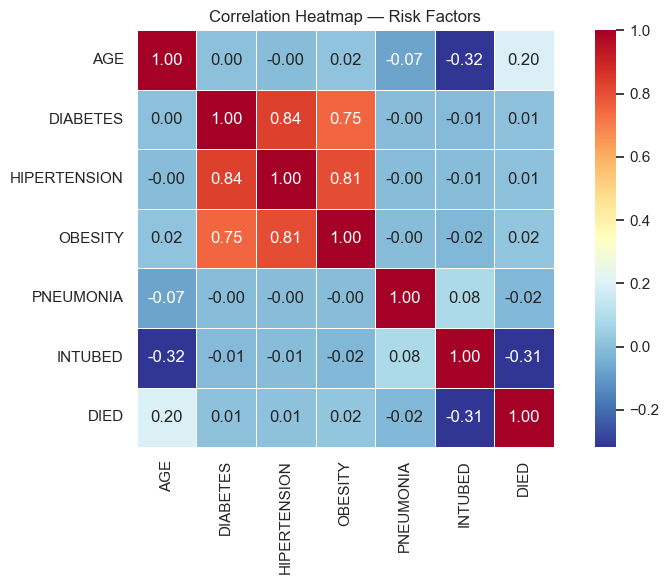

Insight: Pneumonia and intubation show strongest correlation with death.


In [11]:
# 9. Heatmap — Correlation Matrix
cols = [c for c in ['AGE','DIABETES','HIPERTENSION','OBESITY','PNEUMONIA','INTUBED','DIED'] if c in df.columns]

plt.figure(figsize=(9, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlBu_r', linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Risk Factors')
plt.tight_layout()
plt.show()
print('Insight: Pneumonia and intubation show strongest correlation with death.')

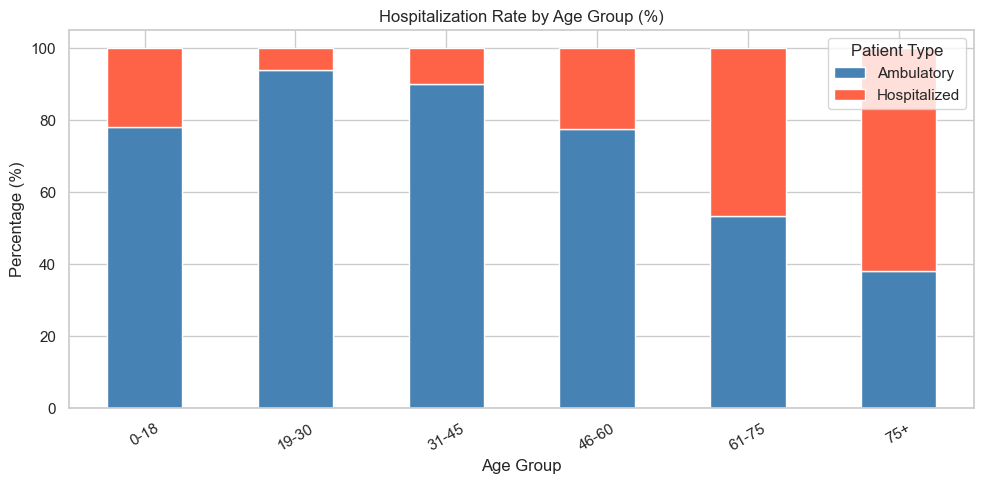

Insight: Hospitalization rate increases sharply after age 60.


In [12]:
# 10. Stacked Bar — Hospitalization by Age Group
df['PATIENT_LABEL'] = df['PATIENT_TYPE'].map({1:'Ambulatory', 2:'Hospitalized'})
stacked = df.groupby(['AGE_GROUP','PATIENT_LABEL'], observed=True).size().unstack(fill_value=0)
stacked_pct = stacked.div(stacked.sum(axis=1), axis=0) * 100

stacked_pct.plot(kind='bar', stacked=True, figsize=(10, 5),
                 color=['steelblue','tomato'], edgecolor='white')
plt.title('Hospitalization Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30)
plt.legend(title='Patient Type')
plt.tight_layout()
plt.show()
print('Insight: Hospitalization rate increases sharply after age 60.')

In [13]:
# 11. Summary
print('='*50)
print('  DATA VISUALIZATION COMPLETE — CODEALPHA TASK 3')
print('='*50)
print('Charts Created:')
print('  1. Bar Chart      — Patient Type Distribution')
print('  2. Pie Chart      — Gender Distribution')
print('  3. KDE Plot       — Age: Survived vs Died')
print('  4. Horizontal Bar — Death Rate by Age Group')
print('  5. Horizontal Bar — Comorbidity Prevalence')
print('  6. Bar Chart      — Death Rate by Gender')
print('  7. Heatmap        — Correlation Matrix')
print('  8. Stacked Bar    — Hospitalization by Age')
print()
print('Tools: Python | Pandas | Matplotlib | Seaborn')
print('='*50)

  DATA VISUALIZATION COMPLETE — CODEALPHA TASK 3
Charts Created:
  1. Bar Chart      — Patient Type Distribution
  2. Pie Chart      — Gender Distribution
  3. KDE Plot       — Age: Survived vs Died
  4. Horizontal Bar — Death Rate by Age Group
  5. Horizontal Bar — Comorbidity Prevalence
  6. Bar Chart      — Death Rate by Gender
  7. Heatmap        — Correlation Matrix
  8. Stacked Bar    — Hospitalization by Age

Tools: Python | Pandas | Matplotlib | Seaborn
